# 24 - Basic CNN for Image Classification

Train a simple Convolutional Neural Network (CNN) on a small image dataset (Fashion-MNIST) and show training, evaluation, and visualizations.

**Problem Statement**

Implement a basic CNN to classify images from a small dataset (e.g., Fashion-MNIST). Keep code simple and well-commented so it can be adapted to other image CSVs or directories.

**Understanding of Dataset**

We use `Fashion-MNIST` (28x28 grayscale, 10 classes) included in `keras.datasets` as a small, standard dataset. In exams you'll likely get a folder of images or a CSV listing image paths — see notes at the end for how to change the loading code.

**Theory**

CNNs learn spatial hierarchies using convolutional filters and pooling. A simple architecture: Conv -> ReLU -> Pool -> Conv -> ReLU -> Pool -> Flatten -> Dense -> Softmax.

**Mathematical Representation**

Convolution: (f * x)(i,j) = sum_m sum_n f(m,n) x(i-m, j-n). Activation: a = ReLU(z) = max(0,z). Softmax for output: softmax(z)_k = exp(z_k)/sum_j exp(z_j). Loss: categorical cross-entropy.

**Pseudocode**

1. Load dataset -> clean/sanity check -> normalize to [0,1]
2. Build simple CNN in Keras
3. Train for few epochs, monitor validation accuracy
4. Evaluate on test set, show sample predictions

In [1]:
# Simple CNN example using Keras (TensorFlow). Comments explain each step.
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Load Fashion-MNIST dataset (small and quick). In exam, replace with your dataset loading code.
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
print('Train shape:', x_train.shape, 'Test shape:', x_test.shape)

Train shape: (60000, 28, 28) Test shape: (10000, 28, 28)


Any NaNs in train? False
Labels distribution (train): [6000 6000 6000 6000 6000 6000 6000 6000 6000 6000]


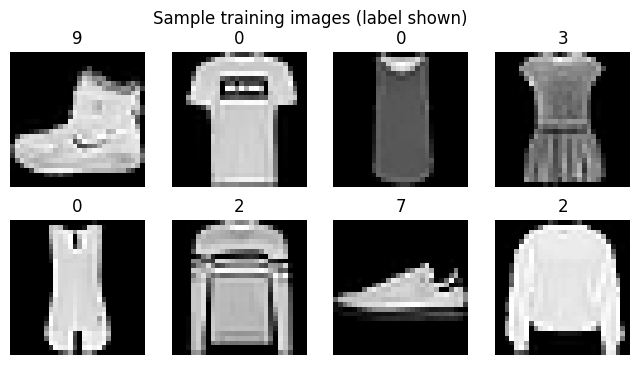

In [2]:
# === Data cleaning / Explaining the data ===
# Check for NaNs and basic stats
print('Any NaNs in train?', np.isnan(x_train).any())
print('Labels distribution (train):', np.bincount(y_train))

# Show a few sample images (EDA)
plt.figure(figsize=(8,4))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(str(y_train[i]))
    plt.axis('off')
plt.suptitle('Sample training images (label shown)')
plt.show()

In [3]:
# === Feature scaling / normalization ===
# Pixel values 0-255 -> normalize to 0-1 for better training
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
# Add channel dimension (grayscale) -> (samples, 28, 28, 1)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

# Convert labels to categorical (one-hot)
num_classes = 10
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat = keras.utils.to_categorical(y_test, num_classes)
print('Shapes after preprocessing:', x_train.shape, y_train_cat.shape)

Shapes after preprocessing: (60000, 28, 28, 1) (60000, 10)


In [4]:
# === Build a simple CNN model ===
def build_simple_cnn(input_shape=(28,28,1), num_classes=10):
    model = keras.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model = build_simple_cnn()
model.summary()

C:\Users\paritosh\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# === Train the model (keep epochs small for example) ===
epochs = 5
history = model.fit(x_train, y_train_cat, epochs=epochs, batch_size=128, validation_split=0.1, verbose=2)

# === Evaluate on test set ===
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)
print('Test accuracy:', test_acc, 'Test loss:', test_loss)

# Save model for later use
model.save('cnn_fashion_mnist_model.h5')
print('Saved model to cnn_fashion_mnist_model.h5')

Epoch 1/5
422/422 - 5s - 12ms/step - accuracy: 0.7908 - loss: 0.5850 - val_accuracy: 0.8505 - val_loss: 0.4162
Epoch 2/5
422/422 - 4s - 9ms/step - accuracy: 0.8686 - loss: 0.3722 - val_accuracy: 0.8645 - val_loss: 0.3694
Epoch 3/5
422/422 - 4s - 9ms/step - accuracy: 0.8832 - loss: 0.3254 - val_accuracy: 0.8727 - val_loss: 0.3449
Epoch 4/5
422/422 - 4s - 8ms/step - accuracy: 0.8936 - loss: 0.2964 - val_accuracy: 0.8895 - val_loss: 0.3140
Epoch 5/5
422/422 - 4s - 9ms/step - accuracy: 0.9003 - loss: 0.2733 - val_accuracy: 0.8950 - val_loss: 0.2863


Test accuracy: 0.88919997215271 Test loss: 0.301777184009552
Saved model to cnn_fashion_mnist_model.h5


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


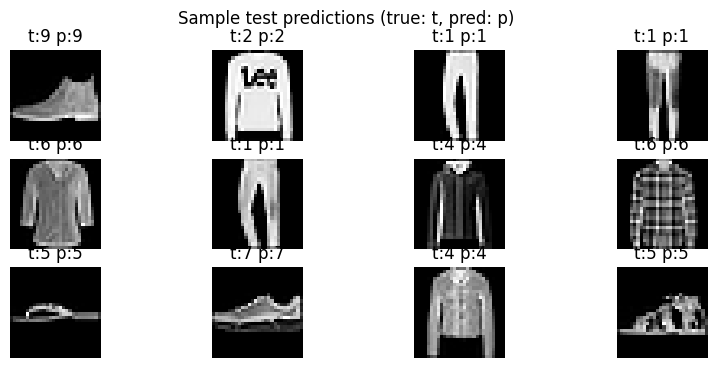

In [6]:
# === Show predictions on a few test images ===
preds = model.predict(x_test[:12])
pred_labels = np.argmax(preds, axis=1)
plt.figure(figsize=(10,4))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    plt.title(f't:{y_test[i]} p:{pred_labels[i]}')
    plt.axis('off')
plt.suptitle('Sample test predictions (true: t, pred: p)')
plt.show()

**Evaluation Matrix**

- Report test accuracy and loss. For more thorough evaluation use confusion matrix and per-class recall/precision.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Confusion Matrix (counts):
[[807   0  15  29   8   2 128   0  11   0]
 [  1 975   1  16   4   0   1   0   2   0]
 [ 14   1 791   9 121   0  62   0   2   0]
 [  8   5   9 901  45   0  31   0   1   0]
 [  0   1  31  21 907   0  38   0   2   0]
 [  0   0   0   0   0 980   0  11   0   9]
 [103   1  69  22 141   0 647   0  17   0]
 [  0   0   0   0   0  21   0 947   0  32]
 [  1   2   2   3   5   1   5   5 976   0]
 [  1   0   0   0   0   6   0  32   0 961]]
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.81      0.83      1000
           1       0.99      0.97      0.98      1000
           2       0.86      0.79      0.82      1000
           3       0.90      0.90      0.90      1000
           4       0.74      0.91      0.81      1000
           5       0.97      0.98      0.98      1000
           6       0.71      0.65      0.68      1000
           7       0.95      0.95      0.95  

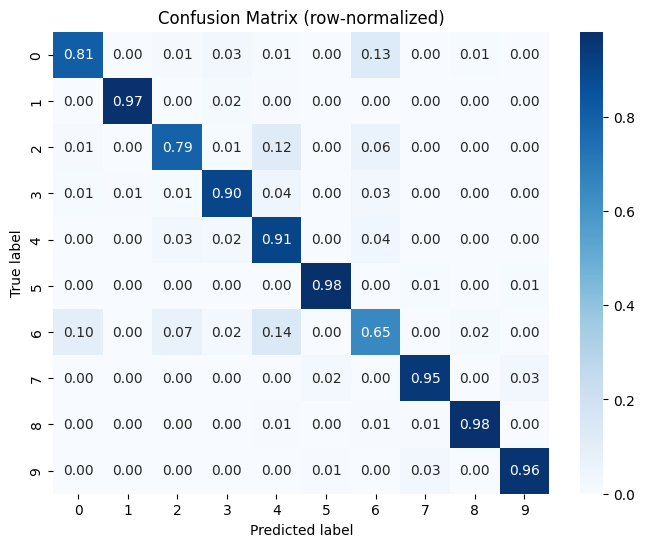

In [7]:
# === Confusion matrix + precision / recall / F1 (on full test set) ===
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score

# Predict labels for the entire test set
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
# True labels are in y_test (integers)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix (counts):')
print(cm)

# Classification report (precision, recall, f1 per class)
print('Classification Report:')
print(classification_report(y_test, y_pred))

# Macro/weighted precision, recall, f1
print('Precision (macro):', precision_score(y_test, y_pred, average='macro'))
print('Recall (macro):', recall_score(y_test, y_pred, average='macro'))
print('F1 (macro):', f1_score(y_test, y_pred, average='macro'))

# Plot confusion matrix heatmap (normalized by true counts for better readability)
import seaborn as sns
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # normalize rows
plt.figure(figsize=(8,6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix (row-normalized)')
plt.show()

**Notes for using a different image dataset (exam)**

- If exam provides a folder of images, use `keras.preprocessing.image_dataset_from_directory()` or `tf.data` pipelines to load images.
- For CSV with image paths, read the CSV, load images with `tf.io.read_file` + `tf.image.decode_image`, then resize/normalize.
- Adjust `input_shape` and `num_classes` according to dataset.
- Increase epochs and batch size depending on compute.